Organizing and streamlining code to identify snow-atmosphere interface from SIMBA temperature data to share.

Steps to identify the surface are:

1. calculate the vertical temperature gradient (dTdz)
2. mask known probelm levels, likely not as big an issue or even necessary for summit data
3. vertically scale masked dTdz
4. calculate varaince in time of dTdz
5. identify surface as the maximum variance in each profile

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import datetime as dt
from sklearn import preprocessing
import csv
from ICECAPS_support_functions import load_raven_sleigh_data

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%m-%d')

#### Functions for sfc id

In [3]:
def load_netcdf(filepath, in_vars):
    """ open netcdf file, load variables (in_vars should be a list) and
        output dictionary of variables"""

    out_vars = {}

    with Dataset(filepath, mode = 'r') as open_netcdf:
        if len(in_vars)>0:
            for var in in_vars:
                out_vars[var] = open_netcdf.variables[var][:]
        else:
            for var in open_netcdf.variables.keys():
                out_vars[var] = open_netcdf.variables[var][:]
    
        try:
            out_vars['time_unit'] = open_netcdf.variables['time'].units
        except:
            None

    return out_vars

In [4]:
def calc_moving_variance(var_in, window):
    for i in range(var_in.shape[0]):
        try:
            time_step_var = np.ma.var(np.ma.masked_invalid(var_in[i-int(window/2):i+int(window/2)+1,:]), axis=0)
        except:
            time_step_var = np.full(var_in.shape[0], -999)

        if i==0:
            rolling_var = time_step_var[np.newaxis,:]
        else:
            rolling_var = np.ma.concatenate((rolling_var, time_step_var[np.newaxis,:]))
    return rolling_var

In [5]:
def mask_variance(var_in, heights_in, dates_in, mask_dict):
    dates_2d = np.repeat(dates_in.copy()[:,np.newaxis], var_in.shape[1], axis=1)
    heights_2d = np.repeat(heights_in.copy()[np.newaxis,:], var_in.shape[0], axis=0)

    data = np.copy(var_in)

    for (d1, d2) in mask_dict:
        mask_height = mask_dict[(d1, d2)]['mask_height']
        if mask_dict[(d1, d2)]['mask_dir'] == 'lessthan':
            data = np.where((dates_2d>=d1)&(dates_2d<d2)&(heights_2d<mask_height), 0, data)
        else:
            data = np.where((dates_2d>=d1)&(dates_2d<d2)&(heights_2d>mask_height), 0, data)
    return data

In [6]:
def mask_then_scale_variance(var_in, heights_in, dates_in, mask_dict=False):
    data = np.copy(var_in)

    if mask_dict:
        data = mask_variance(data, heights_in, dates_in, mask_dict)

    scaled_data = preprocessing.normalize(data, axis=1)
    return scaled_data

In [7]:
def identify_surface(scaled_var_in, heights_in):
    masked_dTdz_var = np.copy(scaled_var_in)
    win_sfc = []
    
    for i in range(masked_dTdz_var.shape[0]):
        timestep_var = masked_dTdz_var[i,:]
        max_height = heights_in[np.ma.where(timestep_var==np.ma.max(timestep_var))[0]]
    
        if len(max_height)!=1:
            win_sfc.append(np.nan)
        else:
            win_sfc.append(max_height[0])
            
    return np.array(win_sfc)

#### Start loading data and making calculations

In [70]:
# simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
h = 28
simba_fname = f'firnprofile-combined-corrected-at{h}.sled.level2.beta.15min.20240517-20240821_created_September_11_2025.nc'
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/corrections_by_height/'


# simba_data = {}
varnames = ['temperature','initial_height','time']
simba_data = load_netcdf(simba_filepath+simba_fname, varnames)

fstart_time = dt.datetime.strptime(simba_data['time_unit'], 'minutes since %Y-%m-%d')
simba_data['dates'] = np.asarray([fstart_time+dt.timedelta(minutes=int(m)) for m in simba_data['time']])

In [71]:
simba_temps = simba_data['temperature']
simba_heights = simba_data['initial_height']
simba_dates = simba_data['dates']

dTdz = np.gradient(simba_temps, simba_heights,  axis=1)


The SIMBA at Raven had some nuances/issues. The 2x4 used as support for the string introduces noise unrelated to the surface. Melt water below the surface also increases the dT/dz variance. I also did some manual tweaking of surface to make the surface and temperature look more realistic.

They key for each entry is a tuple with the start and end times for when the mask is applied. The values are a dictionary that identify the direction of masking ('mask_dir') as either grater than or less than the 'mask_height'.

In [72]:
obs_in_hr = 4 # SIMBA has resolution of 15 minutes, so 4 observations per hour
win_length = 24 # number of hours to calculate variance over

dTdz_variance = calc_moving_variance(dTdz, obs_in_hr*win_length)

In [73]:
simba_dates_2d = np.repeat(simba_dates.copy()[:,np.newaxis], simba_temps.shape[1], axis=1)
simba_heights_2d = np.repeat(simba_heights.copy()[np.newaxis,:], simba_temps.shape[0], axis=0)

In [74]:
pre_scale_masking = {
           #  (dt.datetime(2024,6,10),dt.datetime(2024,6,10)):{'mask_dir':'lessthan','mask_height':10},
           # (dt.datetime(2024,7,19), dt.datetime(2024,7,21)):{'mask_dir':'greaterthan', 'mask_height':45},
           (dt.datetime(2024,6,10), dt.datetime(2024,6,13)):{'mask_dir':'lessthan','mask_height':10},
           (dt.datetime(2024,5,10), dt.datetime(2024,8,13)):{'mask_dir':'greaterthan','mask_height':60},
           (dt.datetime(2024,5,10), dt.datetime(2024,8,20)):{'mask_dir':'lessthan','mask_height':-5},
           # (dt.datetime(2024,7,1), dt.datetime(2024,8,20)):{'mask_dir':'lessthan','mask_height':25},
           # (dt.datetime(2024,7,27), dt.datetime(2024,8,20)):{'mask_dir':'lessthan','mask_height':40},
           (dt.datetime(2024,5,10), dt.datetime(2024,6,27)):{'mask_dir':'greaterthan','mask_height':45},
           (dt.datetime(2024,5,10), dt.datetime(2024,6,15)):{'mask_dir':'greaterthan','mask_height':35},

           # (dt.datetime(2024,6,19,), dt.datetime(2024,6,21)):{'mask_dir':'greaterthan', 'mask_height':20},
           # (dt.datetime(2024,6,9), dt.datetime(2024,6,13,12)):{'mask_dir':'greaterthan','mask_height':25},
           # (dt.datetime(2024,6,5), dt.datetime(2024,6,12)):{'mask_dir':'greaterthan','mask_height':20},

           (dt.datetime(2024,6,15), dt.datetime(2024,7,1)):{'mask_dir':'lessthan','mask_height':20},
           # (dt.datetime(2024,5,28), dt.datetime(2024,5,31)):{'mask_dir':'greaterthan','mask_height':8},

           # (dt.datetime(2024,6,13), dt.datetime(2024,6,14,12)):{'mask_dir':'greaterthan','mask_height':20},
           # (dt.datetime(2024,6,17,12), dt.datetime(2024,6,18,12)):{'mask_dir':'greaterthan','mask_height':20},
           # (dt.datetime(2024,6,14), dt.datetime(2024,6,18)):{'mask_dir':'greaterthan','mask_height':25},
           # (dt.datetime(2024,7,16), dt.datetime(2024,7,19)):{'mask_dir':'greaterthan','mask_height':48},
           # (dt.datetime(2024,6,8), dt.datetime(2024,6,10)):{'mask_dir':'greaterthan','mask_height':18},
           # (dt.datetime(2024,6,3), dt.datetime(2024,6,5)):{'mask_dir':'greaterthan','mask_height':12},

           (simba_dates[0], simba_dates[-1]):{'mask_dir':'greaterthan','mask_height':100},
           (simba_dates[0], simba_dates[-1]):{'mask_dir':'lessthan','mask_height':-50},
}

In [75]:
dTdz_variance_scaled = mask_then_scale_variance(dTdz_variance, simba_heights, simba_dates, mask_dict=pre_scale_masking)

In [76]:
simba_sfc = identify_surface(dTdz_variance_scaled, simba_heights)

In [77]:
## deal with window artifact in beginning - 
## I didn't do the same for the end because the SIMBA data extends beyond the SLEIGH data I'm using
mean_early_sfc_idx = np.where((simba_dates>dt.datetime(2024,5,17))&(simba_dates<dt.datetime(2024,5,18)))[0]
simba_sfc[np.where(simba_dates<dt.datetime(2024,5,18))] = np.nanmean( simba_sfc[mean_early_sfc_idx])

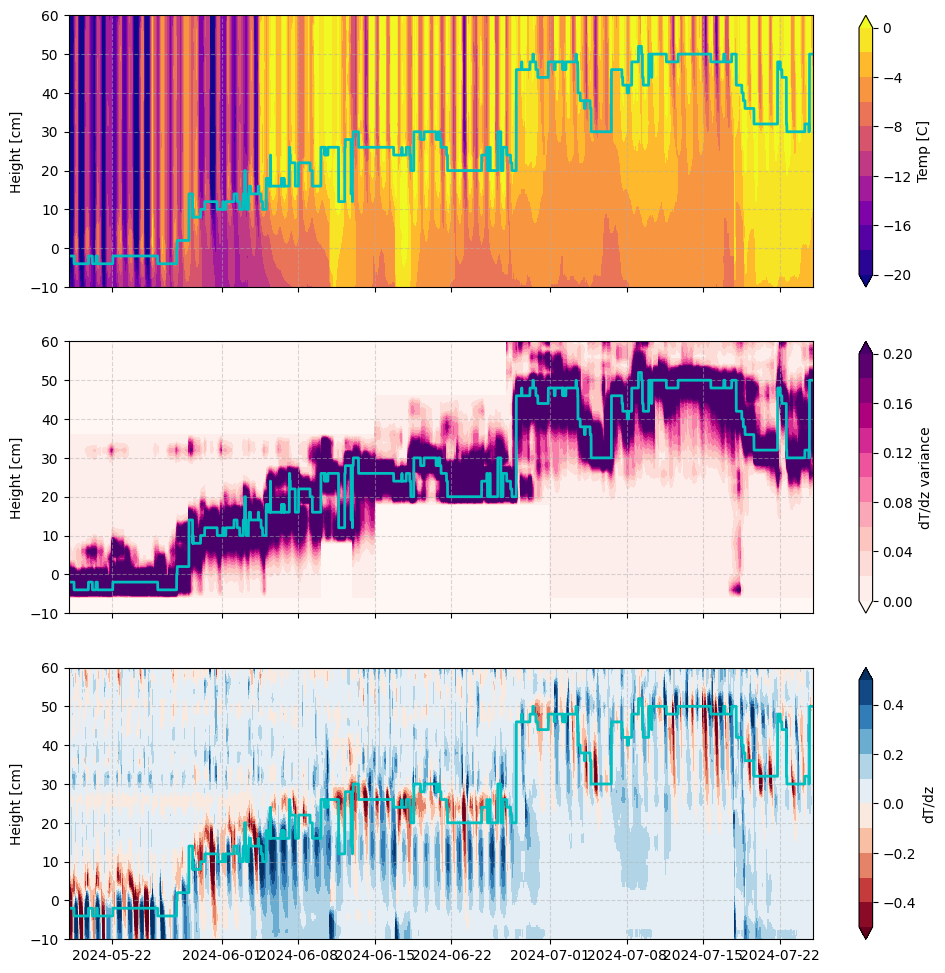

In [78]:
fig, axs = plt.subplots(3, figsize=(12,12), sharex=True, sharey=True)

labels = ['Temp [C]', 'dT/dz variance', 'dT/dz']
cmaps = [plt.cm.plasma, plt.cm.RdPu, plt.cm.RdBu]
levels = [np.arange(-20,1,2), np.arange(0,.21,.02), np.arange(-.5,.51,.1)]

for i, (ax, var) in enumerate(zip(axs.ravel(),[simba_temps, dTdz_variance_scaled, dTdz])):
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(var,0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(simba_dates, simba_sfc, c='c', lw=2)
    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
axs[1].set_ylim(-10,60)
axs[1].set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
plt.show()

#### Backup: compare dT/dz for different splices

In [86]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

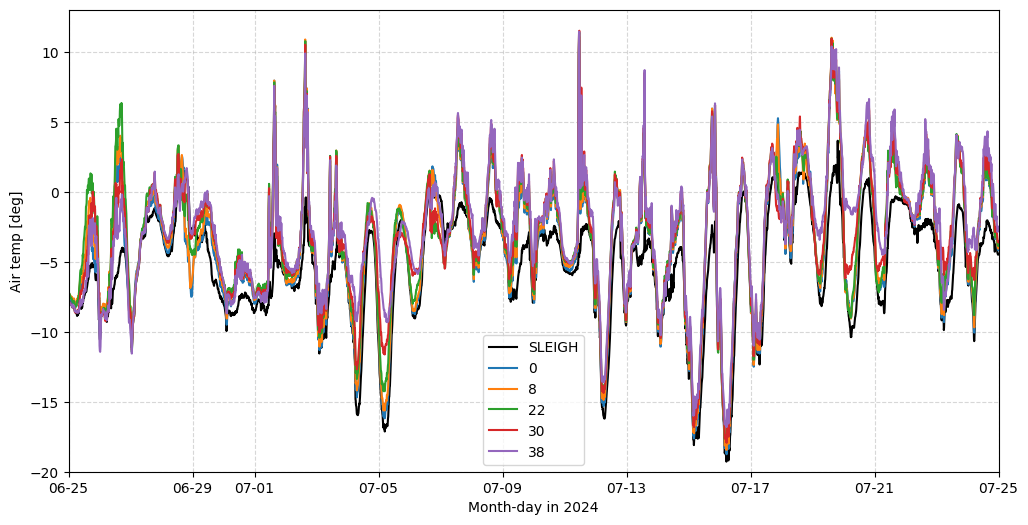

In [98]:
# simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
h = 28

fig_air, ax_air = plt.subplots(1, figsize=(12,6))

ax_air.plot(asfs_data_lev2['dates'], asfs_data_lev2['temp'], label='SLEIGH', c='k')
ax_air.set_ylabel('Air temp [deg]')
ax_air.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
ax_air.xaxis.set_major_formatter(myFmt)
ax_air.set_xlabel('Month-day in 2024')
ax_air.grid(alpha=.5, ls='--')

for h in [0, 8, 22, 30, 38]:
    simba_fname = f'firnprofile-combined-corrected-at{h}.sled.level2.beta.15min.20240517-20240821_created_September_11_2025.nc'
    simba_filepath = '/psd3data/arctic/sledd/Raven_simba/corrections_by_height/'
    
    
    # simba_data = {}
    varnames = ['temperature','initial_height','time']
    simba_data = load_netcdf(simba_filepath+simba_fname, varnames)
    
    fstart_time = dt.datetime.strptime(simba_data['time_unit'], 'minutes since %Y-%m-%d')
    simba_data['dates'] = np.asarray([fstart_time+dt.timedelta(minutes=int(m)) for m in simba_data['time']])


    simba_temps = simba_data['temperature']
    simba_heights = simba_data['initial_height']
    simba_dates = simba_data['dates']

    ax_air.plot(simba_dates, simba_temps[:,-1], label=h)
    
    dTdz = np.gradient(simba_temps, simba_heights,  axis=1)


    # fig, ax = plt.subplots(1, figsize=(12,6), sharex=True, sharey=True)
    # cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(dTdz,0,1),
    #                 cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    # ax.plot(asfs_data_lev2['dates'], asfs_data_lev2['snow_gpr_dist'], c='k')
    # ax.set_ylabel('Height [cm]')
    # plt.colorbar(cb, label='dT/dz', ax=ax)
    # ax.grid(alpha=.5, ls='--')
        
    # ax.set_ylim(-10,60)
    # ax.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
    # ax.xaxis.set_major_formatter(myFmt)
    # ax.set_xlabel('Month-day in 2024')
    # plt.title(h)
    
ax_air.set_ylim(-20,13)
ax_air.set_xlim(dt.datetime(2024,6,25), dt.datetime(2024,7,25))
ax_air.legend(loc='best')
plt.show()

negative dT/dz above thermistor is partially a function of splice height??